In [1]:
# ============================================
# Setup Colab: GPU + Drive
# ============================================

import os
from pathlib import Path

COLAB = "google.colab" in str(get_ipython())

if COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

    !nvidia-smi
else:
    print("Running locally")

Mounted at /content/drive
Tue Apr 14 12:57:36 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    Off |   00000000:05:00.0 Off |                    0 |
| N/A   31C    P0             46W /  600W |       0MiB /  97887MiB |      0%      Default |
|                                         |                        |             Disabled |
+---------------------

In [2]:
# ============================================
# Paths configuration
# ============================================

if COLAB:
    DRIVE_ROOT = Path("/content/drive/MyDrive/bootcamp_project/data/dataset")
    LOCAL_SSD_ROOT = Path("/content/dataset")

    # Dataset source on Drive
    DRIVE_DATASET_DIR = DRIVE_ROOT

    # Dataset destination on SSD
    LOCAL_DATASET_DIR = LOCAL_SSD_ROOT

    LOCAL_DATASET_DIR.mkdir(parents=True, exist_ok=True)

    print("Drive dataset:", DRIVE_DATASET_DIR)
    print("Local SSD dataset:", LOCAL_DATASET_DIR)

Drive dataset: /content/drive/MyDrive/bootcamp_project/data/dataset
Local SSD dataset: /content/dataset


### Optimize Dataset Copying with Tarball

Copying many small files can be inefficient. To speed up the process and make it more robust across Colab sessions, we'll create a single compressed archive (tar.gz) of the dataset on Google Drive. This archive will be created only once. In subsequent runs, we'll just copy this single tarball to the local SSD and extract it, which is significantly faster than copying individual files. We'll also check if the local dataset is already present to avoid unnecessary operations.

In [ ]:
import shutil

tar_filename = "dataset.tar.gz"
DRIVE_TAR_PATH = DRIVE_DATASET_DIR.parent / tar_filename
LOCAL_TAR_PATH = LOCAL_SSD_ROOT / tar_filename

if COLAB:
    print("\n--- Optimizing Dataset Loading ---")
    print("Checking for dataset tarball on Drive...")
    if not DRIVE_TAR_PATH.exists():
        print(f"Creating tarball '{tar_filename}' from '{DRIVE_DATASET_DIR.name}' in '{DRIVE_DATASET_DIR.parent}'...")
        # Create a tar.gz archive of the dataset directory
        shutil.make_archive(
            str(DRIVE_TAR_PATH.with_suffix('')), # make_archive adds .tar.gz itself
            'gztar',
            root_dir=DRIVE_DATASET_DIR.parent, # The directory containing the folder to archive
            base_dir=DRIVE_DATASET_DIR.name   # The folder to archive
        )
        print(f"✓ Tarball created at {DRIVE_TAR_PATH}")
    else:
        print(f"✓ Tarball already exists at {DRIVE_TAR_PATH}")

    # Check if LOCAL_DATASET_DIR is already populated to skip re-extraction
    # This is useful if a previous run in the same session already extracted the data
    if LOCAL_DATASET_DIR.exists() and any(LOCAL_DATASET_DIR.iterdir()): # Check if directory exists and is not empty
        print("✓ Local dataset directory is already populated. Skipping tarball extraction.")
    else:
        print(f"Copying tarball from Drive to local SSD: {DRIVE_TAR_PATH} -> {LOCAL_TAR_PATH}")
        shutil.copy2(DRIVE_TAR_PATH, LOCAL_TAR_PATH)
        print(f"✓ Tarball copied to local SSD.")

        print(f"Extracting tarball to {LOCAL_SSD_ROOT}...")
        shutil.unpack_archive(LOCAL_TAR_PATH, LOCAL_SSD_ROOT)
        print(f"✓ Tarball extracted.")

        # Clean up the copied tarball to save space on SSD
        LOCAL_TAR_PATH.unlink()
        print(f"✓ Local tarball removed: {LOCAL_TAR_PATH}")

    print("--- Dataset loading optimization complete ---")
else:
    print("Local run — no tarball needed.")

In [3]:
import shutil
from tqdm import tqdm
import os
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed # Added imports

def copy_file_task(src_file, dst_file):
    """Helper function to copy a single file."""
    if not dst_file.exists():
        shutil.copy2(src_file, dst_file)

def copy_tree(src, dst, num_workers=8):
    src = Path(src)
    dst = Path(dst)

    # First, collect all files and create necessary directories
    files_to_copy = []
    for root, dirs, files in os.walk(src):
        rel = Path(root).relative_to(src)
        target_dir = dst / rel
        target_dir.mkdir(parents=True, exist_ok=True)

        for f in files:
            src_file = Path(root) / f
            dst_file = target_dir / f
            files_to_copy.append((src_file, dst_file))

    # Filter out files that already exist to avoid unnecessary copies
    files_to_copy_filtered = [
        (s_file, d_file) for s_file, d_file in files_to_copy if not d_file.exists()
    ]

    total_files = len(files_to_copy_filtered)

    if total_files == 0:
        print("No new files to copy.")
        return

    print(f"Copying {total_files} files...")

    # Use ThreadPoolExecutor for parallel copying with tqdm progress bar
    with ThreadPoolExecutor(max_workers=num_workers) as executor:
        futures = [executor.submit(copy_file_task, s_file, d_file) for s_file, d_file in files_to_copy_filtered]
        for _ in tqdm(as_completed(futures), total=total_files, desc="Copying dataset"):
            pass

# ============================================
# Copy dataset from Drive → SSD local
# ============================================

if COLAB:
    print("Copying dataset to local SSD...")
    copy_tree(DRIVE_DATASET_DIR, LOCAL_DATASET_DIR) # Call the modified function
    print("✓ Dataset copied to SSD")
else:
    print("Local run — no copy needed.")

Copying dataset to local SSD...
Copying 58872 files...


Copying dataset: 100%|██████████| 58872/58872 [32:04<00:00, 30.59it/s]

✓ Dataset copied to SSD


In [4]:
# ============================================
# Login to Weight and bias to track progress
# ============================================

import wandb
wandb.login()

wandb.init(
    project="certification",
    config={
        "batch_size": 32,
        "mixup_alpha": 0.2,
        "label_smoothing": 0.1,
        "model": "efficientnet-b3",
        "optimizer": "Adam",
        "scheduler": "CosineAnnealingLR"
    }
)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: jimmy-ouellet (jimmy-ouellet-personnal) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [6]:
! pip install efficientnet_pytorch

  Preparing metadata (setup.py) ... done
  Created wheel for efficientnet_pytorch: filename=efficientnet_pytorch-0.7.1-py3-none-any.whl size=16426 sha256=50c1f12851b4f461163899a6f885dd55f077d728260e7960ff8f06126e11ae68
  Stored in directory: /root/.cache/pip/wheels/9c/3f/43/e6271c7026fe08c185da2be23c98c8e87477d3db63f41f32ad
Successfully built efficientnet_pytorch


In [7]:
# ============================================
# Imports
# ============================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
from torch.utils.data import Dataset
from PIL import Image
import numpy as np
from tqdm import tqdm
from efficientnet_pytorch import EfficientNet
from collections import Counter

In [8]:
# ============================================
# Data Augmentation
# ============================================

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(300, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.25, hue=0.05),
    transforms.RandomPerspective(distortion_scale=0.3, p=0.5),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

val_transforms = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

In [22]:
import os
import shutil
from pathlib import Path
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# === CONFIG ===
DATASET_DIR = Path("/content/dataset/")  # dossier avec 1 classe = 1 dossier
SPLIT_DIR   = Path("/content/dataset_split")

TRAIN_DIR = SPLIT_DIR / "train"
VAL_DIR   = SPLIT_DIR / "val"

TRAIN_DIR.mkdir(parents=True, exist_ok=True)
VAL_DIR.mkdir(parents=True, exist_ok=True)

classes = sorted([
    d.name for d in DATASET_DIR.iterdir()
    if d.is_dir() and not d.name.startswith(".")
])

print(f"{len(classes)} classes détectées.")
print(classes)

for cls in tqdm(classes, desc="Splitting classes"):
    print(cls)
    src = DATASET_DIR / cls
    print(src)
    images = [f for f in os.listdir(src) if f.lower().endswith((".jpg", ".jpeg", ".png"))]

    # Split 80% train / 20% val
    train_imgs, val_imgs = train_test_split(images, test_size=0.2, random_state=42)

    # Create class folders
    (TRAIN_DIR / cls).mkdir(parents=True, exist_ok=True)
    (VAL_DIR / cls).mkdir(parents=True, exist_ok=True)

    # Copy images
    for img in train_imgs:
        shutil.copy2(src / img, TRAIN_DIR / cls / img)

    for img in val_imgs:
        shutil.copy2(src / img, VAL_DIR / cls / img)

print("✓ Split terminé.")
print("Train dir :", TRAIN_DIR)
print("Val dir   :", VAL_DIR)

58 classes détectées.
['allium', 'angelica', 'apple', 'avocado', 'basil', 'bird_of_paradise', 'blackberry', 'blueberry', 'borage', 'chamomile', 'cherry', 'chives', 'chrysanthemum', 'coriander', 'cosmos', 'cranberry', 'daisy', 'dill', 'fennel', 'fig', 'foxglove', 'freesia', 'gerbera', 'grape', 'gypsophila', 'hellebore', 'hydrangea', 'hyssop', 'iris', 'kiwi', 'lavender', 'lemon', 'lemongrass', 'lemonverbena', 'lily', 'lisianthus', 'lovage', 'mango', 'melon', 'mint', 'mugwort', 'oregano', 'parsley', 'peach', 'pear', 'poppy', 'ranunculus', 'raspberry', 'rosemary', 'sage', 'savory', 'strawberry', 'sunflower', 'tarragon', 'thyme', 'wintergreen', 'wisteria', 'zinnia']


Splitting classes:   3%|▎         | 2/58 [00:00<00:03, 16.74it/s]

allium
/content/dataset/allium
angelica
/content/dataset/angelica
apple
/content/dataset/apple
avocado
/content/dataset/avocado


Splitting classes:  10%|█         | 6/58 [00:00<00:02, 18.17it/s]

basil
/content/dataset/basil
bird_of_paradise
/content/dataset/bird_of_paradise
blackberry
/content/dataset/blackberry
blueberry
/content/dataset/blueberry


...

rosemary
/content/dataset/rosemary
sage
/content/dataset/sage
savory
/content/dataset/savory
strawberry
/content/dataset/strawberry


Splitting classes:  91%|█████████▏| 53/58 [00:03<00:00, 17.89it/s]

sunflower
/content/dataset/sunflower
tarragon
/content/dataset/tarragon
thyme
/content/dataset/thyme


Splitting classes: 100%|██████████| 58/58 [00:03<00:00, 17.16it/s]

wintergreen
/content/dataset/wintergreen
wisteria
/content/dataset/wisteria
zinnia
/content/dataset/zinnia
✓ Split terminé.
Train dir : /content/dataset_split/train
Val dir   : /content/dataset_split/val


In [28]:
train_dir = Path("/content/dataset_split/train/")
val_dir   = Path("/content/dataset_split/val/")

train_ds = datasets.ImageFolder(train_dir, transform=train_transforms)
val_ds   = datasets.ImageFolder(val_dir,   transform=val_transforms)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=4)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=4)

num_classes = len(train_ds.classes)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes, device

(58, device(type='cuda'))

In [13]:
# ============================================
# Dataset Loaders
# ============================================

train_ds = ImageFolder(train_dir, transform=train_transforms)
val_ds   = ImageFolder(val_dir,   transform=val_transforms)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=4)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=4)

num_classes = len(train_ds.classes)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes, device

NameError: name 'train_dir' is not defined

In [50]:
class_counts = Counter(train_ds.targets)
np.array(list(class_counts.values()))

array([ 800,  772,  800,  800,  896,  602,  800,  800,  874,  904,  762,
       1263,  800,  722,  800,  800,  800,  856,  927,  800,  800,  800,
        800,  800,  800,  800,  800,  907,  800,  351, 1032,  800,  832,
        754,  800,  800,  340,  800,  799,  955,  880,  850,  872,  799,
        800,  800,  800,  800,  983,  849,  488,  800,  800,  811, 1132,
        879,  800,  800])

In [52]:
# ============================================
# Create a matrix for the class imbalance
# ============================================

#classes = sorted(train_ds["name"].unique())
#num_classes = len(classes)

class_counts2 = Counter(train_ds.targets)
class_counts = np.array(list(class_counts2.values()))
beta = 0.9999  # recommandé
#counts = np.array([class_counts[i] for i in range(num_classes)])

effective_num = 1.0 - np.power(beta, class_counts)
weights = (1.0 - beta) / effective_num
weights = weights / np.sum(weights) * num_classes  # normalisation

class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

for cls, w, c in zip(classes, weights, class_counts):
    print(f"{cls:20s}  weight={w:.4f}   count={c}")


allium                weight=0.9747   count=800
angelica              weight=1.0087   count=772
apple                 weight=0.9747   count=800
avocado               weight=0.9747   count=800
basil                 weight=0.8744   count=896
bird_of_paradise      weight=1.2827   count=602
blackberry            weight=0.9747   count=800
blueberry             weight=0.9747   count=800
borage                weight=0.8954   count=874
chamomile             weight=0.8670   count=904
cherry                weight=1.0214   count=762
chives                weight=0.6316   count=1263
chrysanthemum         weight=0.9747   count=800
coriander             weight=1.0759   count=722
cosmos                weight=0.9747   count=800
cranberry             weight=0.9747   count=800
daisy                 weight=0.9747   count=800
dill                  weight=0.9135   count=856
fennel                weight=0.8465   count=927
fig                   weight=0.9747   count=800
foxglove              weight=0.9747   c

In [53]:
idx_to_class = {v: k for k, v in train_ds.class_to_idx.items()}

In [54]:
# ============================================
# Mixup
# ============================================

def mixup_data(x, y, alpha=0.2):
    if alpha <= 0:
        return x, y, 1.0

    lam = np.random.beta(alpha, alpha)
    batch_size = x.size()[0]
    index = torch.randperm(batch_size)

    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam


def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

In [55]:
# ============================================
# EfficientNet-B3
# ============================================

model = EfficientNet.from_pretrained("efficientnet-b3")
model._fc = nn.Linear(model._fc.in_features, num_classes)
model = model.to(device)

Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b3-5fb5a3c3.pth" to /root/.cache/torch/hub/checkpoints/efficientnet-b3-5fb5a3c3.pth


100%|██████████| 47.1M/47.1M [00:00<00:00, 134MB/s]


Loaded pretrained weights for efficientnet-b3


In [56]:
# ============================================
# Train & Validation
# ============================================

def train_one_epoch(model, loader, optimizer, criterion, mixup_alpha=0.2):
    model.train()
    total, correct, total_loss = 0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        x, y_a, y_b, lam = mixup_data(x, y, alpha=mixup_alpha)

        optimizer.zero_grad()
        preds = model(x)
        loss = mixup_criterion(criterion, preds, y_a, y_b, lam)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        _, predicted = preds.max(1)
        correct += (lam * predicted.eq(y_a).sum().item()
                    + (1 - lam) * predicted.eq(y_b).sum().item())
        total += x.size(0)

    return total_loss / total, correct / total


def validate(model, loader, criterion):
    model.eval()
    total, correct, total_loss = 0, 0, 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            preds = model(x)
            loss = criterion(preds, y)

            total_loss += loss.item() * x.size(0)
            _, predicted = preds.max(1)
            correct += predicted.eq(y).sum().item()
            total += x.size(0)

    return total_loss / total, correct / total

In [57]:
# ============================================
# Phase 1 — Feature Extraction
# ============================================

for param in model.parameters():
    param.requires_grad = False

for param in model._fc.parameters():
    param.requires_grad = True

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.1)
optimizer = optim.Adam(model._fc.parameters(), lr=1e-3)
scheduler = CosineAnnealingLR(optimizer, T_max=5)

EPOCHS = 5

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = validate(model, val_loader, criterion)
    scheduler.step()

    print(f"Phase 1 — Epoch {epoch+1}/{EPOCHS} | "
          f"train acc {train_acc:.3f} | val acc {val_acc:.3f}")

    wandb.log({
    "train_loss": train_loss,
    "train_acc": train_acc,
    "val_loss": val_loss,
    "val_acc": val_acc,
    "epoch": epoch
    })


Phase 1 — Epoch 1/5 | train acc 0.370 | val acc 0.584
Phase 1 — Epoch 2/5 | train acc 0.438 | val acc 0.617
Phase 1 — Epoch 3/5 | train acc 0.458 | val acc 0.625
Phase 1 — Epoch 4/5 | train acc 0.466 | val acc 0.634
Phase 1 — Epoch 5/5 | train acc 0.478 | val acc 0.641


In [58]:
# ============================================
# Phase 2 — Fine-tuning complet
# ============================================

for param in model.parameters():
    param.requires_grad = True

optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=15)

best_acc = 0
EPOCHS = 15

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = validate(model, val_loader, criterion)
    scheduler.step()

    print(f"Phase 2 — Epoch {epoch+1}/{EPOCHS} | "
          f"train acc {train_acc:.3f} | val acc {val_acc:.3f}")

    wandb.log({
    "train_loss": train_loss,
    "train_acc": train_acc,
    "val_loss": val_loss,
    "val_acc": val_acc,
    "epoch": epoch
    })

    # Save best model
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")

        artifact = wandb.Artifact("efficientnet_b3_best", type="model")
        artifact.add_file("best_model.pth")
        wandb.log_artifact(artifact)

        print(f"✓ Nouveau meilleur modèle sauvegardé (acc={best_acc:.4f})")



wandb: WARNING Saving files without folders. If you want to preserve subdirectories pass base_path to wandb.save, i.e. wandb.save("/mnt/folder/file.h5", base_path="/mnt")
wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Phase 2 — Epoch 1/15 | train acc 0.629 | val acc 0.852
  ✓ Best model saved to Drive as well as WandB server
Phase 2 — Epoch 2/15 | train acc 0.718 | val acc 0.878
  ✓ Best model saved to Drive as well as WandB server
Phase 2 — Epoch 3/15 | train acc 0.766 | val acc 0.898
  ✓ Best model saved to Drive as well as WandB server
Phase 2 — Epoch 4/15 | train acc 0.786 | val acc 0.908
  ✓ Best model saved to Drive as well as WandB server
Phase 2 — Epoch 5/15 | train acc 0.806 | val acc 0.913
  ✓ Best model saved to Drive as well as WandB server
Phase 2 — Epoch 6/15 | train acc 0.817 | val acc 0.915
  ✓ Best model saved to Drive as well as WandB server
Phase 2 — Epoch 7/15 | train acc 0.834 | val acc 0.921
  ✓ Best model saved to Drive as well as WandB server
Phase 2 — Epoch 8/15 | train acc 0.839 | val acc 0.926
  ✓ Best model saved to Drive as well as WandB server
Phase 2 — Epoch 9/15 | train acc 0.847 | val acc 0.925
Phase 2 — Epoch 10/15 | train acc 0.843 | val acc 0.929
  ✓ Best model sa

In [63]:
artifact = wandb.Artifact("efficientnet_b3_best", type="model")
artifact.add_file("/content/drive/MyDrive/efficientnet_b3_best.pth")
wandb.log_artifact(artifact)


<Artifact efficientnet_b3_best>

                  precision    recall  f1-score   support

          allium       0.88      0.81      0.84       200
        angelica       0.95      0.99      0.97       193
           apple       0.87      0.85      0.86       200
         avocado       0.88      0.84      0.86       200
           basil       0.97      0.96      0.96       224
bird_of_paradise       0.98      0.99      0.98       151
      blackberry       0.90      0.81      0.85       200
       blueberry       0.91      0.94      0.92       200
          borage       1.00      1.00      1.00       219
       chamomile       0.93      0.99      0.96       226
          cherry       0.84      0.91      0.88       191
          chives       0.95      0.97      0.96       316
   chrysanthemum       0.85      0.73      0.79       200
       coriander       0.91      0.96      0.93       181
          cosmos       0.98      0.94      0.96       200
       cranberry       0.91      0.95      0.93       200
           da

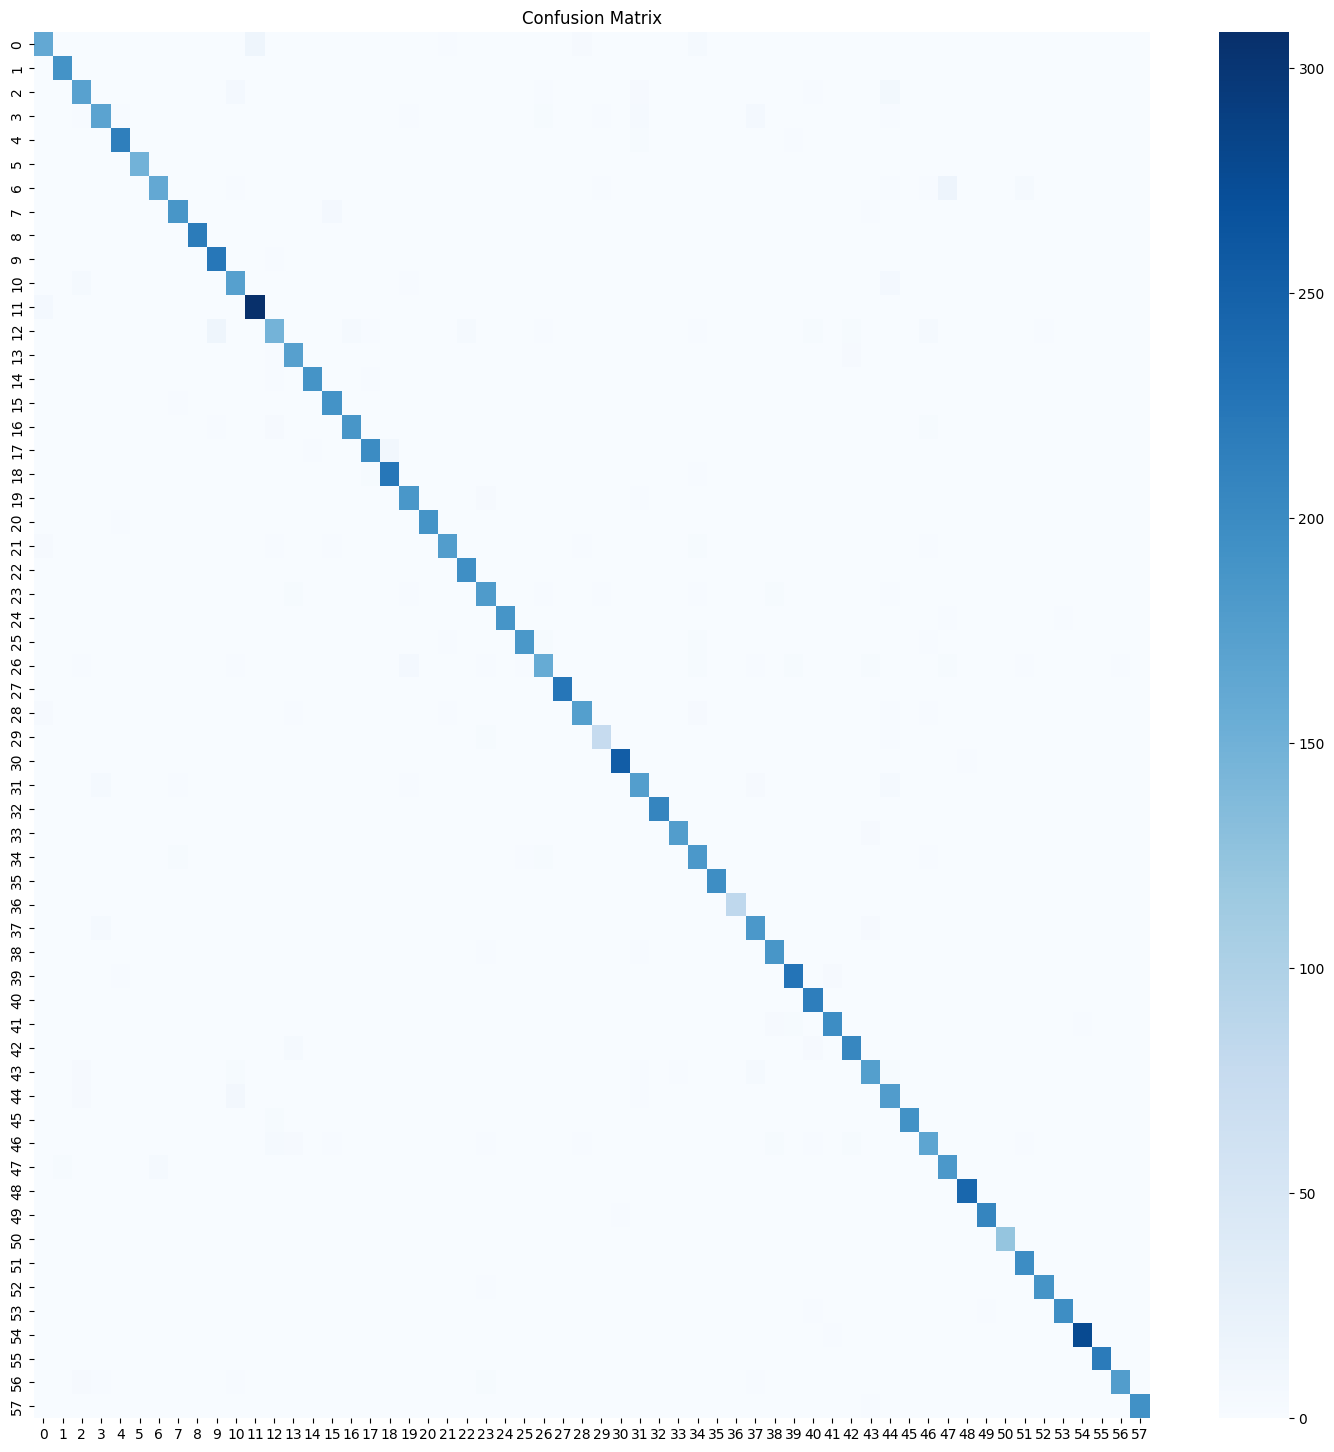

<Figure size 640x480 with 0 Axes>

In [61]:
# ============================================
# Generation and saving of the best model confusion matrix as well as the F1 and recall score
# ============================================

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute predictions
y_true, y_pred = [], []

model.eval()
with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)
        preds = model(x)
        _, predicted = preds.max(1)

        y_true.extend(y.numpy())
        y_pred.extend(predicted.cpu().numpy())

# Classification report
report = classification_report(y_true, y_pred, target_names = train_ds.classes, output_dict=True)
print(classification_report(y_true, y_pred, target_names = train_ds.classes))

# Log to W&B
wandb.log({"classification_report": report})

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(18, 18))
sns.heatmap(cm, annot=False, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

wandb.log({"confusion_matrix": wandb.Image(plt)})

In [60]:
# ============================================
# Load Best Model
# ============================================

model.load_state_dict(torch.load("/content/drive/MyDrive/efficientnet_b3_best.pth"))
model.eval()
print("Best model loaded.")

Best model loaded.
